In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sys
import os

# Set scientific plotting style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# 加载训练集和测试集
train_path = '../../DataSplit/TrainTest/Train.csv'
test_path = '../../DataSplit/TrainTest/Test.csv'

df_train = pd.read_csv(train_path, parse_dates=['time'])
df_test = pd.read_csv(test_path, parse_dates=['time'])

print("训练集形状:", df_train.shape)
print("测试集形状:", df_test.shape)
df_train.head()

训练集形状: (97814, 5)
测试集形状: (11808, 5)


,id,time,gl,age,bmi
0,3,2012-01-01 00:00:00,89.539216,61.0,33.8
1,3,2012-01-01 00:05:00,90.070728,61.0,33.8
2,3,2012-01-01 00:10:00,90.366300,61.0,33.8
3,3,2012-01-01 00:15:00,90.450442,61.0,33.8
4,3,2012-01-01 00:20:00,90.347662,61.0,33.8


In [3]:
def create_dataset(data, n_past, prediction_horizon=1):
    """
    创建滑动窗口数据集
    返回: X (n_samples, n_features), y (n_samples,)
    注意: X 的前 n_past 列是时序血糖值，最后 2 列是 Age 和 BMI
    """
    X, y = [], []
    
    for subject_id, group in data.groupby('id'):
        # 确保按时间排序
        group = group.sort_values('time')
        
        gl_values = group['gl'].values
        age = group['age'].iloc[0] 
        bmi = group['bmi'].iloc[0] 
        
        if len(gl_values) < n_past + prediction_horizon:
            continue

        for i in range(n_past, len(gl_values) - prediction_horizon + 1):
            past_gl = gl_values[i-n_past:i]
            features = np.append(past_gl, [age, bmi])
            X.append(features)
            y.append(gl_values[i + prediction_horizon - 1])
            
    return np.array(X), np.array(y)

# 设定参数
N_PAST = 12 
PREDICTION_HORIZON = 6

print(f"正在构建数据集 (N_PAST={N_PAST}, Horizon={PREDICTION_HORIZON})...")
X_train, y_train = create_dataset(df_train, N_PAST, PREDICTION_HORIZON)
X_test, y_test = create_dataset(df_test, N_PAST, PREDICTION_HORIZON)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

正在构建数据集 (N_PAST=12, Horizon=6)...
X_train shape: (95026, 14), y_train shape: (95026,)


In [4]:
# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("标准化完成。")

标准化完成。


In [5]:
# --- PyTorch 数据准备 ---

class GlucoseDataset(Dataset):
    def __init__(self, X, y, n_past):
        # X shape: (N, n_past + 2)
        # Split into sequence (glucose) and static (age, bmi)
        
        # LSTM expects input shape: (Batch, Seq_Len, Input_Size)
        # So we unsqueeze at dim=2 to get (N, n_past, 1)
        self.X_seq = torch.FloatTensor(X[:, :n_past]).unsqueeze(2) 
        
        self.X_static = torch.FloatTensor(X[:, n_past:])           # (N, 2)
        self.y = torch.FloatTensor(y).unsqueeze(1)                 # (N, 1)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]

# 创建 DataLoader
batch_size = 64
train_dataset = GlucoseDataset(X_train_scaled, y_train, N_PAST)
test_dataset = GlucoseDataset(X_test_scaled, y_test, N_PAST)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoader created. Batch size: {batch_size}")

DataLoader created. Batch size: 64


In [6]:
# --- 定义 LSTM 模型 ---

class GlucoseLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, static_len):
        super(GlucoseLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Layer
        # batch_first=True -> (batch, seq, feature)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully Connected Layers
        # Input: LSTM output (last time step) + static features
        self.fc1 = nn.Linear(hidden_size + static_len, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x_seq, x_static):
        # x_seq: (Batch, Seq_Len, Input_Size)
        
        # Initialize hidden state and cell state
        h0 = torch.zeros(self.num_layers, x_seq.size(0), self.hidden_size).to(x_seq.device)
        c0 = torch.zeros(self.num_layers, x_seq.size(0), self.hidden_size).to(x_seq.device)
        
        # Forward propagate LSTM
        # out: (batch, seq_len, hidden_size)
        out, _ = self.lstm(x_seq, (h0, c0))
        
        # Decode the hidden state of the last time step
        out = out[:, -1, :]
        
        # Concatenate with static features
        out = torch.cat((out, x_static), dim=1)
        
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Hyperparameters
input_size = 1      # 只有一个特征：血糖值
hidden_size = 32    # 隐藏层大小
num_layers = 1      # LSTM 层数
static_len = 2      # 静态特征数量 (Age, BMI)

model = GlucoseLSTM(input_size, hidden_size, num_layers, static_len).to(device)
print(model)

GlucoseLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc1): Linear(in_features=34, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)


In [7]:
# --- 训练模型 ---

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
train_losses = []
val_losses = []

print("开始训练 LSTM 模型...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for x_seq, x_static, y in train_loader:
        x_seq, x_static, y = x_seq.to(device), x_static.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model(x_seq, x_static)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_seq, x_static, y in test_loader:
            x_seq, x_static, y = x_seq.to(device), x_static.to(device), y.to(device)
            outputs = model(x_seq, x_static)
            loss = criterion(outputs, y)
            val_loss += loss.item()
    
    epoch_val_loss = val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

print("训练完成。")

开始训练 LSTM 模型...
Epoch [5/50], Train Loss: 58.0042, Val Loss: 40.2559
Epoch [10/50], Train Loss: 44.4177, Val Loss: 36.6285
Epoch [15/50], Train Loss: 40.9791, Val Loss: 26.0600
Epoch [20/50], Train Loss: 39.6590, Val Loss: 24.8277
Epoch [25/50], Train Loss: 38.7333, Val Loss: 23.5559
Epoch [30/50], Train Loss: 37.9130, Val Loss: 23.3395
Epoch [35/50], Train Loss: 37.0422, Val Loss: 23.5585
Epoch [40/50], Train Loss: 36.2423, Val Loss: 22.4873
Epoch [45/50], Train Loss: 35.7745, Val Loss: 22.1269
Epoch [50/50], Train Loss: 35.1609, Val Loss: 21.8604
训练完成。


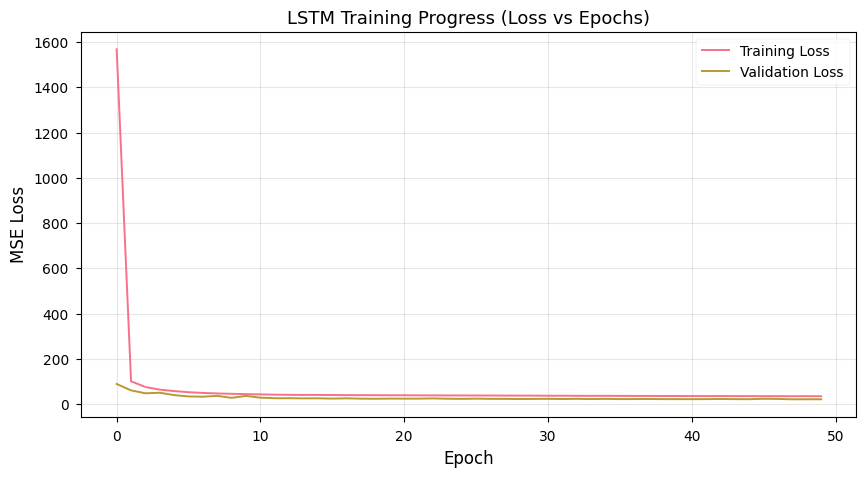

In [8]:
# --- 绘制训练过程 ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('LSTM Training Progress (Loss vs Epochs)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# --- 保存模型 ---
model_save_path = 'lstm_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"模型已保存至: {os.path.abspath(model_save_path)}")

模型已保存至: c:\Users\江一骏\Desktop\学习\HKU\dissertation\engineering\code\GlucosePrediction\src\Prediction\LSTM\lstm_model.pth


In [10]:
# --- 测试集评估 ---
model.eval()
y_pred_list = []
y_true_list = []

with torch.no_grad():
    for x_seq, x_static, y in test_loader:
        x_seq, x_static = x_seq.to(device), x_static.to(device)
        outputs = model(x_seq, x_static)
        y_pred_list.extend(outputs.cpu().numpy())
        y_true_list.extend(y.numpy())

y_pred = np.array(y_pred_list).flatten()
y_test_np = np.array(y_true_list).flatten()

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100
    return mae, rmse, mape, rmspe

mae, rmse, mape, rmspe = calculate_metrics(y_test_np, y_pred)

print("\n" + "=" * 60)
print(f"📊 LSTM 评估结果 (Horizon={PREDICTION_HORIZON}, {PREDICTION_HORIZON*5} mins)")
print("=" * 60)
print(f"MAE:   {mae:.4f} mg/dL")
print(f"RMSE:  {rmse:.4f} mg/dL")
print(f"MAPE:  {mape:.4f}%")
print(f"RMSPE: {rmspe:.4f}%")
print("=" * 60)


📊 LSTM 评估结果 (Horizon=6, 30 mins)
MAE:   3.2355 mg/dL
RMSE:  4.6657 mg/dL
MAPE:  2.9656%
RMSPE: 4.0967%


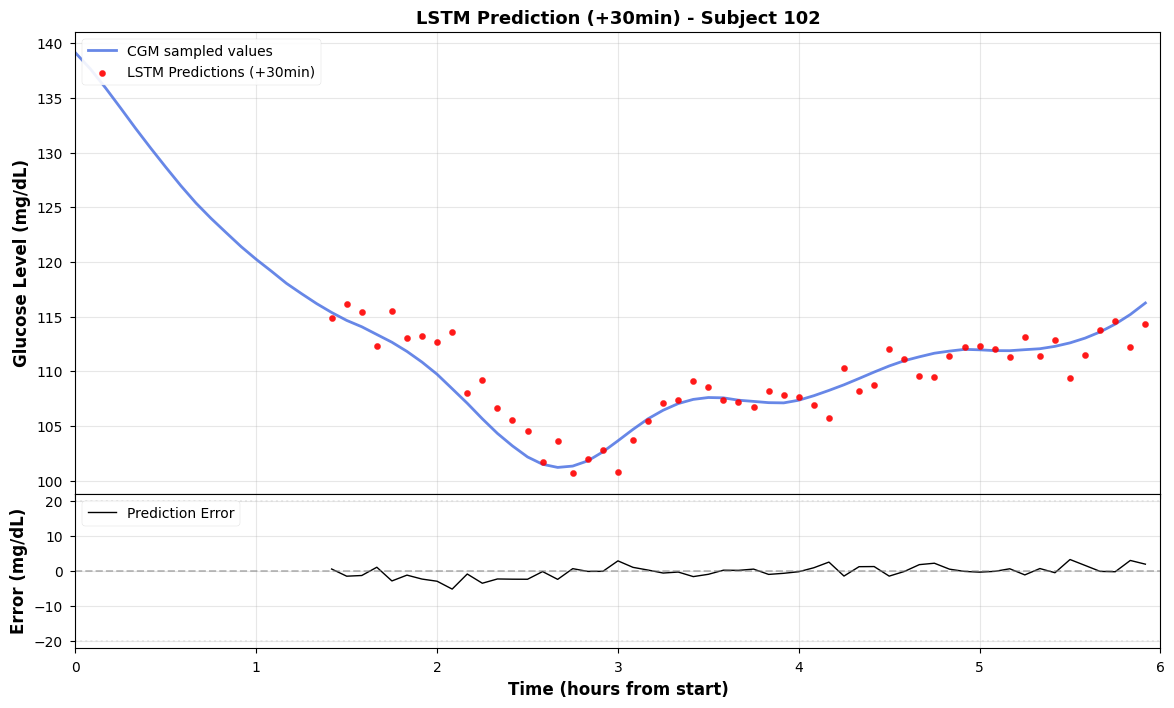

Subject 102 (MAPE 1.20%): Visualization generated.


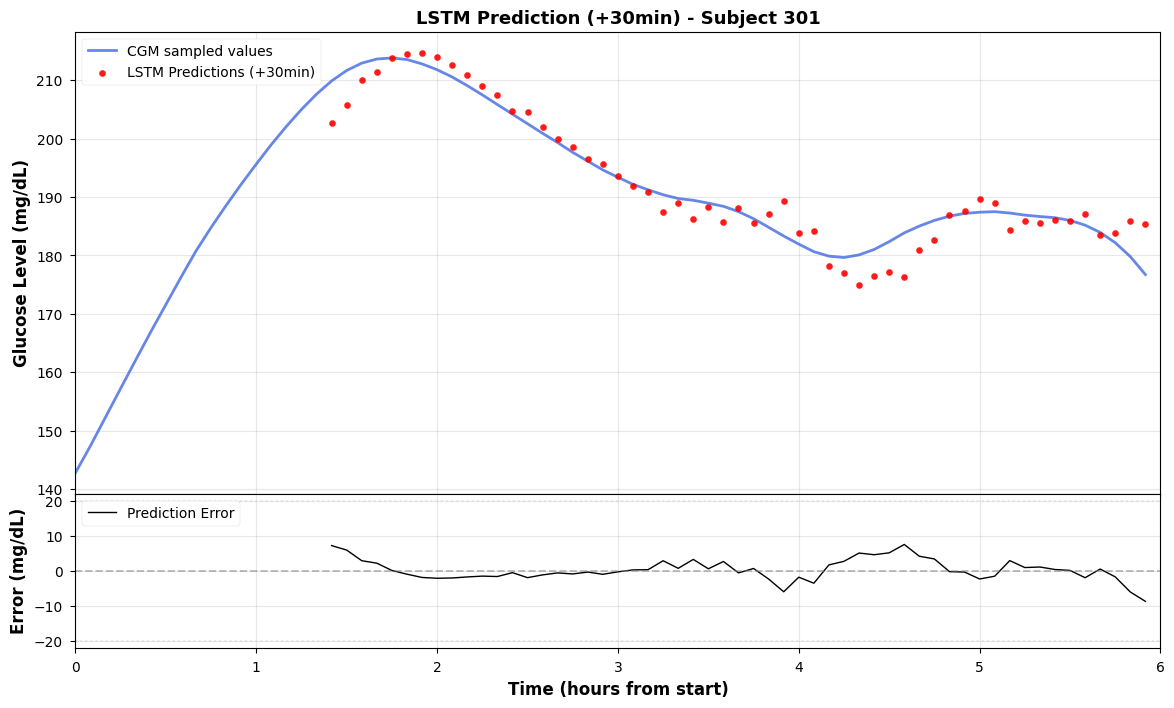

Subject 301 (MAPE 1.20%): Visualization generated.


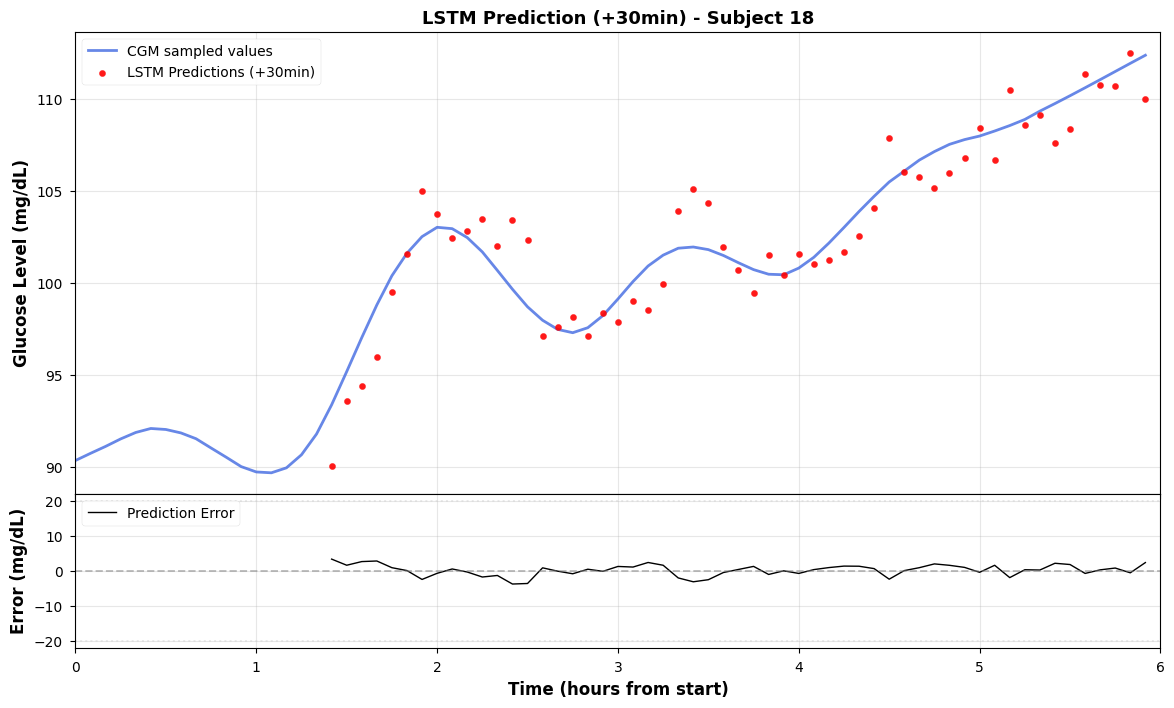

Subject 18 (MAPE 1.28%): Visualization generated.


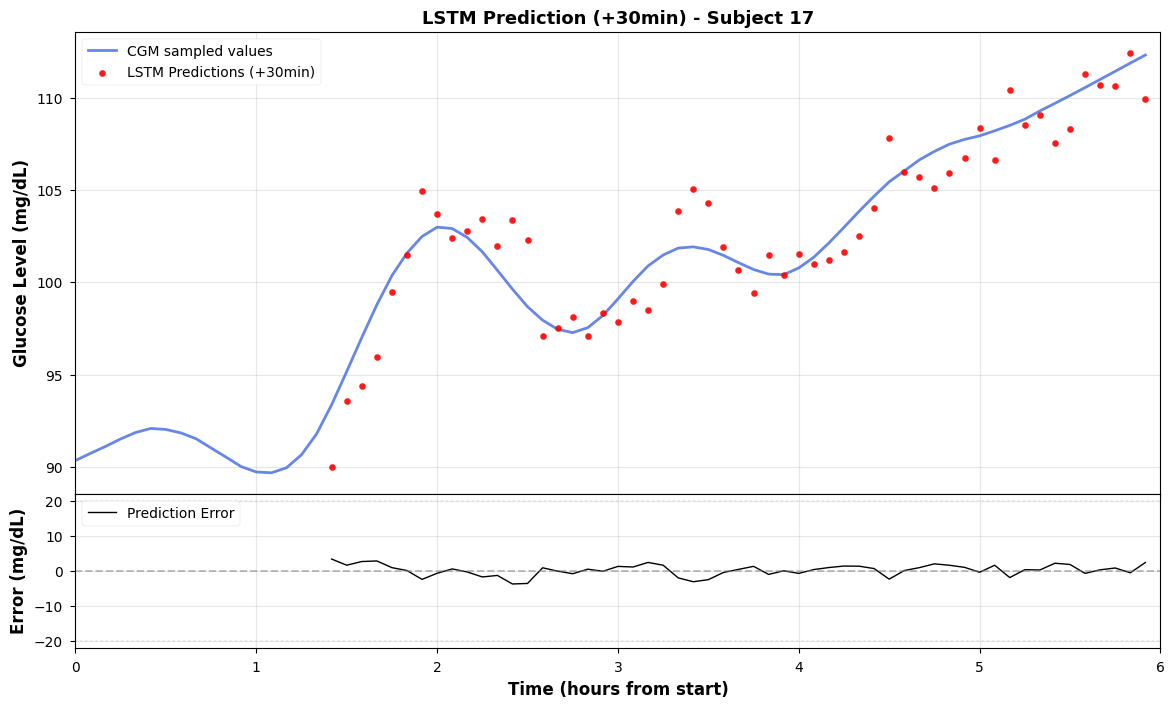

Subject 17 (MAPE 1.28%): Visualization generated.


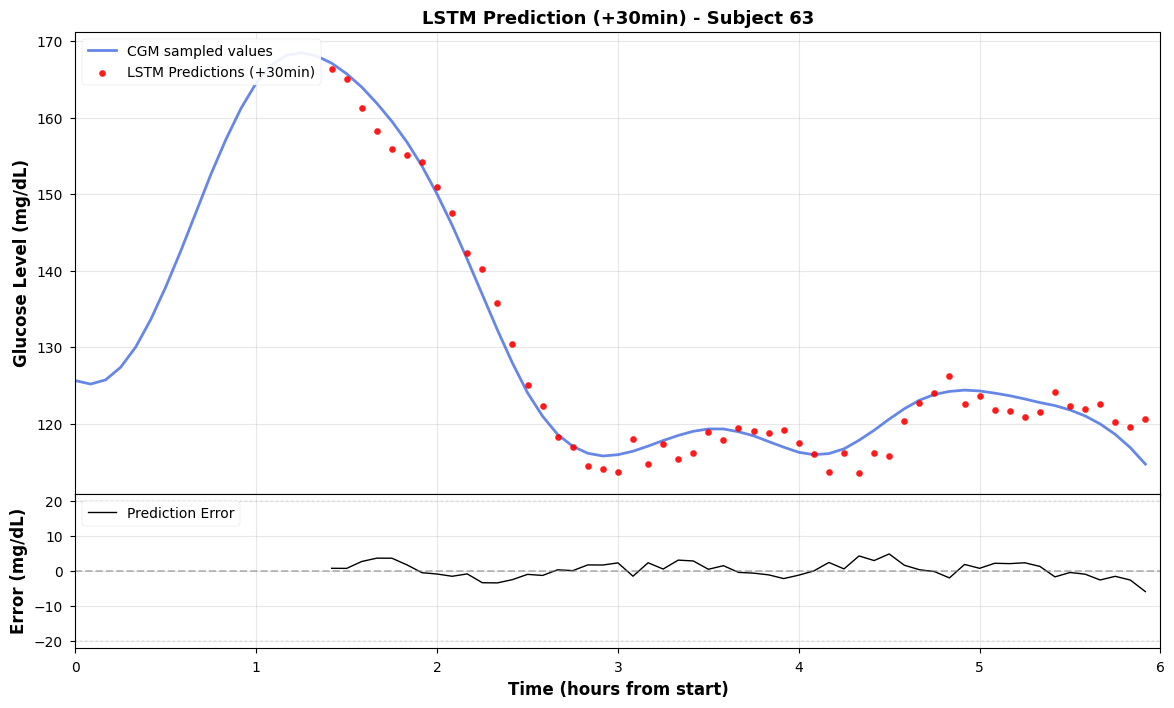

Subject 63 (MAPE 1.41%): Visualization generated.


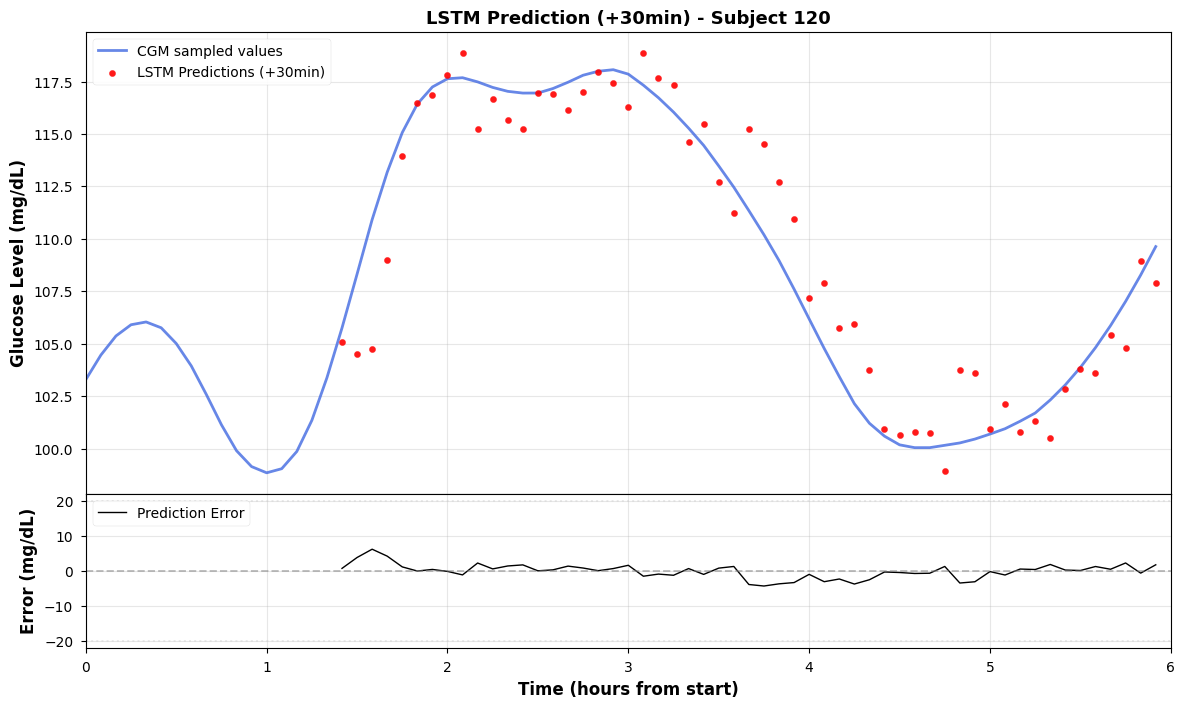

Subject 120 (MAPE 1.42%): Visualization generated.


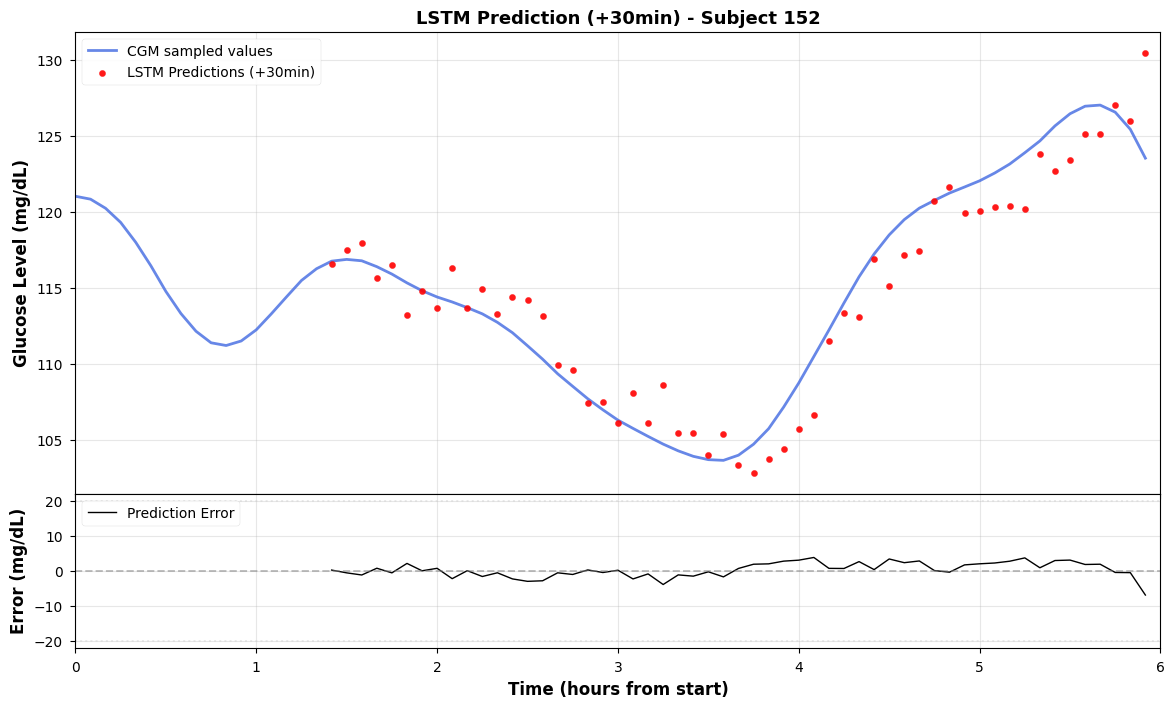

Subject 152 (MAPE 1.45%): Visualization generated.


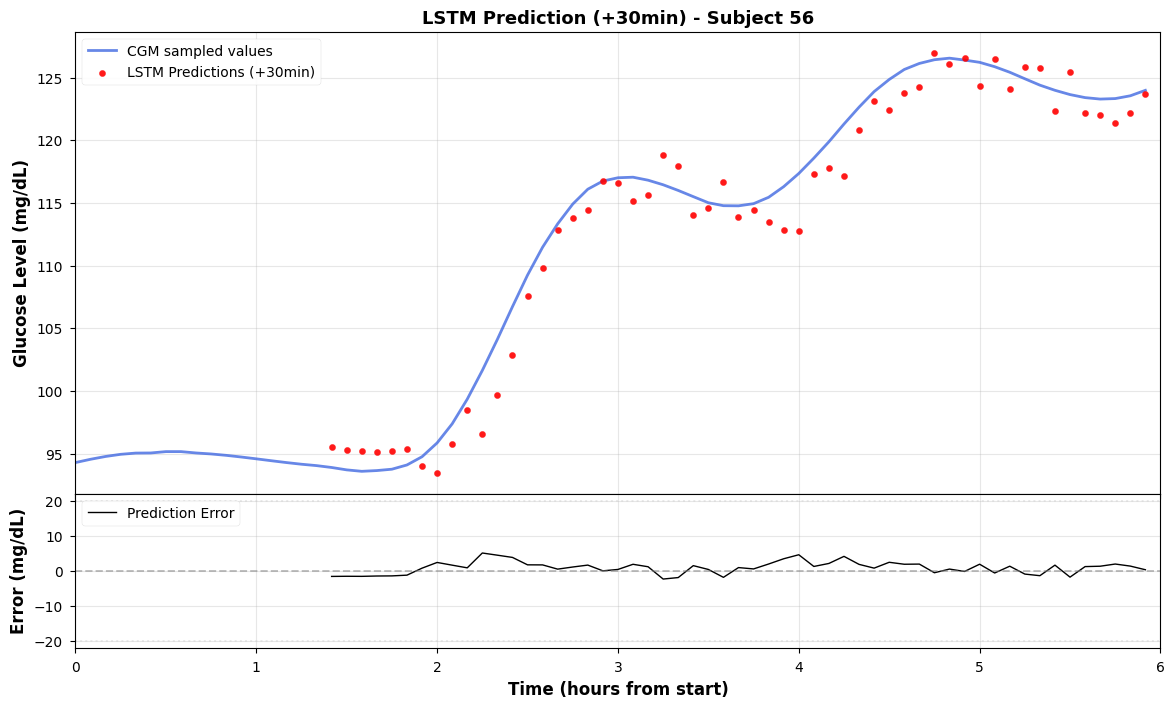

Subject 56 (MAPE 1.47%): Visualization generated.


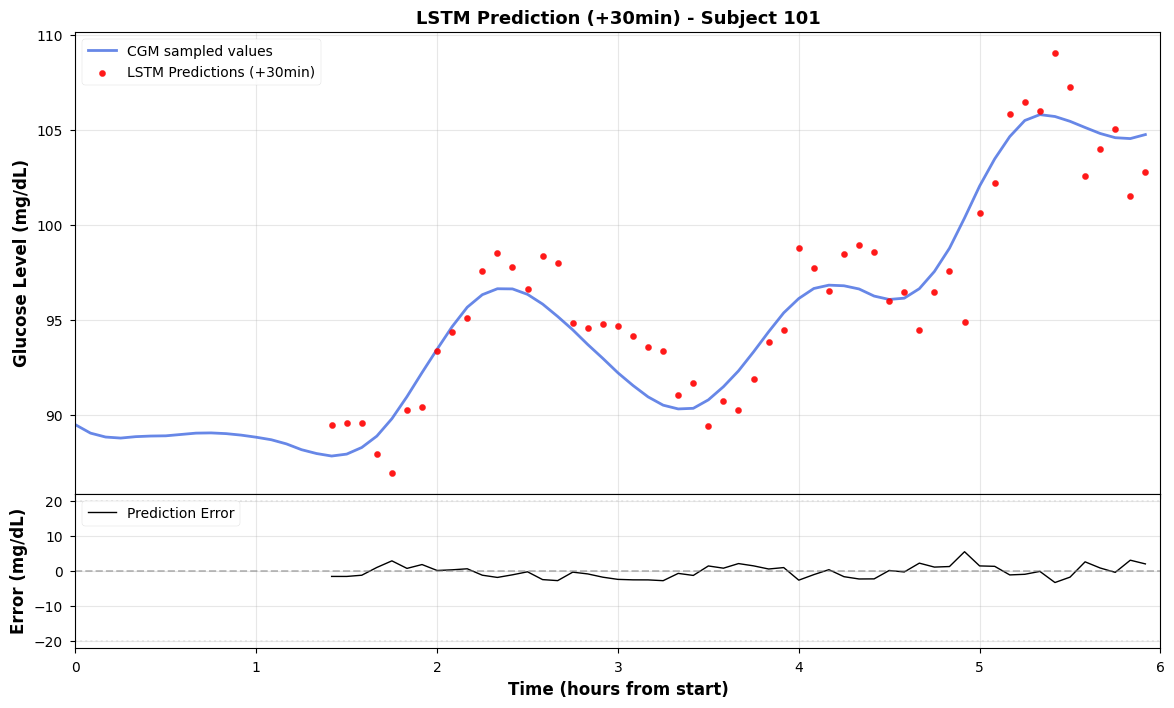

Subject 101 (MAPE 1.59%): Visualization generated.


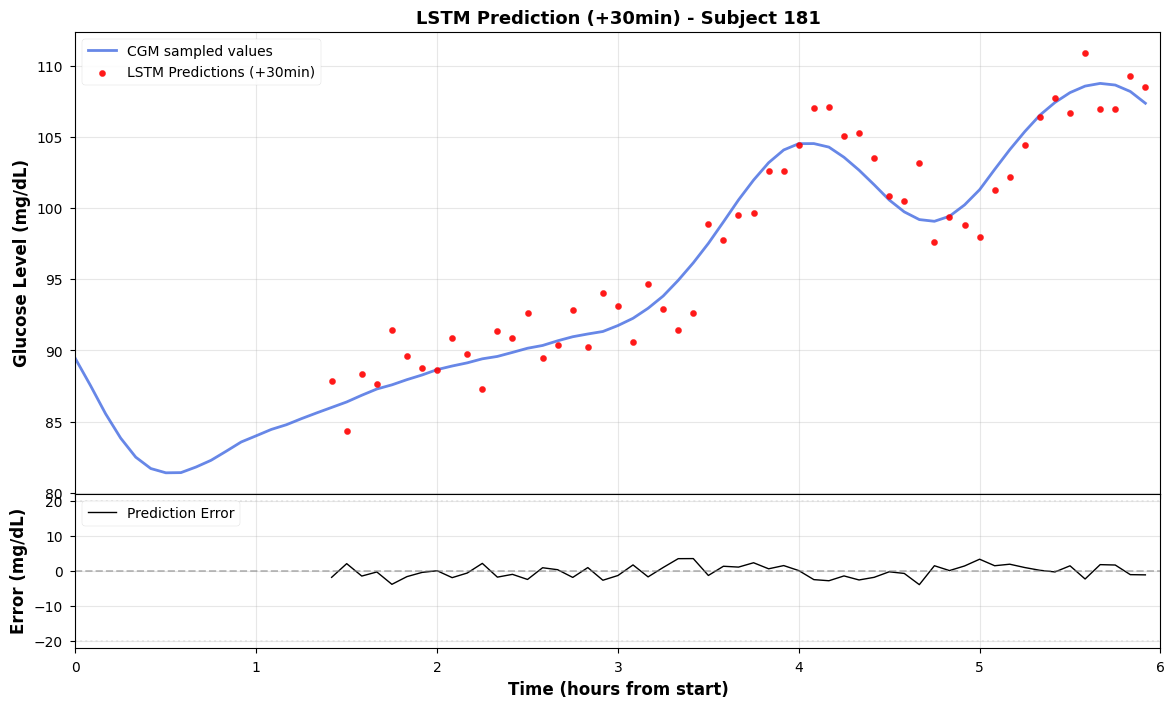

Subject 181 (MAPE 1.62%): Visualization generated.


In [11]:
# --- 可视化测试集预测结果 ---
import matplotlib.dates as mdates

# 获取测试集中所有受试者的 ID（已排序）
subject_ids = sorted(df_test['id'].unique())

# 先计算每个受试者的 MAPE，用于挑选前 10 名
subject_stats = []

current_pred_idx = 0

for subject_id in subject_ids:
    # 提取该受试者数据
    subject_data = df_test[df_test['id'] == subject_id].copy().sort_values('time')
    gl_values = subject_data['gl'].values
    
    # 计算该受试者的有效样本数
    n_valid = len(gl_values) - N_PAST - PREDICTION_HORIZON + 1
    
    if n_valid <= 0:
        continue

    # 提取该受试者的预测值
    y_pred_subj = y_pred[current_pred_idx : current_pred_idx + n_valid]
    
    # 真实值
    y_true_subj = gl_values[N_PAST + PREDICTION_HORIZON - 1 : N_PAST + PREDICTION_HORIZON - 1 + n_valid]
    
    current_pred_idx += n_valid

    # 计算 MAPE
    mask = y_true_subj != 0
    if mask.any():
        mape_subj = np.mean(np.abs((y_true_subj[mask] - y_pred_subj[mask]) / y_true_subj[mask])) * 100
    else:
        mape_subj = np.nan

    subject_stats.append({
        'id': subject_id,
        'mape': mape_subj,
        'data': subject_data,
        'y_true': y_true_subj,
        'y_pred': y_pred_subj,
    })

# 按 MAPE 升序取前 10 个受试者
subject_stats = [s for s in subject_stats if not np.isnan(s['mape'])]
subject_stats = sorted(subject_stats, key=lambda x: x['mape'])[:10]

# 绘图
for stat in subject_stats:
    subject_id = stat['id']
    subject_data = stat['data']
    y_true_subj = stat['y_true']
    y_pred_subj = stat['y_pred']
    error = y_true_subj - y_pred_subj

    # 构造时间轴
    full_hours = np.arange(len(subject_data)) * (5 / 60)
    # 预测值对应的时间点
    pred_hours = full_hours[N_PAST + PREDICTION_HORIZON - 1 : N_PAST + PREDICTION_HORIZON - 1 + len(y_pred_subj)]

    y_true_full = subject_data['gl'].values

    # 绘图
    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(14, 8), 
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0}
    )
    
    ax1.plot(full_hours, y_true_full, label='CGM sampled values', color='royalblue', linewidth=2, alpha=0.8)
    ax1.scatter(pred_hours, y_pred_subj, label=f'LSTM Predictions (+{PREDICTION_HORIZON*5}min)', color='red', s=20, alpha=0.9, zorder=5)
    ax1.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
    ax1.set_title(f'LSTM Prediction (+{PREDICTION_HORIZON*5}min) - Subject {subject_id}', fontweight='bold')
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(pred_hours, error, label='Prediction Error', color='black', linewidth=1)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.axhline(y=-20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.set_ylabel('Error (mg/dL)', fontweight='bold')
    ax2.set_xlabel('Time (hours from start)', fontweight='bold')
    ax2.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    
    ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0f}'))
    ax2.set_xlim(0, 6)

    plt.show()
    print(f"Subject {subject_id} (MAPE {stat['mape']:.2f}%): Visualization generated.")

In [12]:
# --- 模拟真实场景：Served Set 预测 ---
print("\n🚀 模拟真实场景：加载保存的模型对 Served Set 进行预测...")

# 1. 加载数据
served_path = '../../DataSplit/Served/served.csv'
df_served = pd.read_csv(served_path, parse_dates=['time'])
X_served, y_served = create_dataset(df_served, N_PAST, PREDICTION_HORIZON)

# 2. 预处理 (使用之前的 scaler)
X_served_scaled = scaler.transform(X_served)

# 3. 创建 DataLoader
served_dataset = GlucoseDataset(X_served_scaled, y_served, N_PAST)
served_loader = DataLoader(served_dataset, batch_size=batch_size, shuffle=False)

# 4. 加载模型
# 重新初始化模型结构
loaded_model = GlucoseLSTM(input_size, hidden_size, num_layers, static_len).to(device)
loaded_model.load_state_dict(torch.load('lstm_model.pth'))
loaded_model.eval()
print("模型加载成功！")

# 5. 预测
y_pred_served_list = []
with torch.no_grad():
    for x_seq, x_static, y in served_loader:
        x_seq, x_static = x_seq.to(device), x_static.to(device)
        outputs = loaded_model(x_seq, x_static)
        y_pred_served_list.extend(outputs.cpu().numpy())

y_pred_served = np.array(y_pred_served_list).flatten()

# 6. 评估
mae_s, rmse_s, mape_s, rmspe_s = calculate_metrics(y_served, y_pred_served)
print("-" * 30)
print(f"Served Set 评估结果 (Loaded Model):")
print(f"MAE: {mae_s:.4f} mg/dL")
print(f"RMSE: {rmse_s:.4f} mg/dL")
print(f"MAPE: {mape_s:.4f}%")
print(f"RMSPE: {rmspe_s:.4f}%")
print("-" * 30)


🚀 模拟真实场景：加载保存的模型对 Served Set 进行预测...
模型加载成功！
------------------------------
Served Set 评估结果 (Loaded Model):
MAE: 5.0236 mg/dL
RMSE: 8.1853 mg/dL
MAPE: 4.2701%
RMSPE: 6.7352%
------------------------------


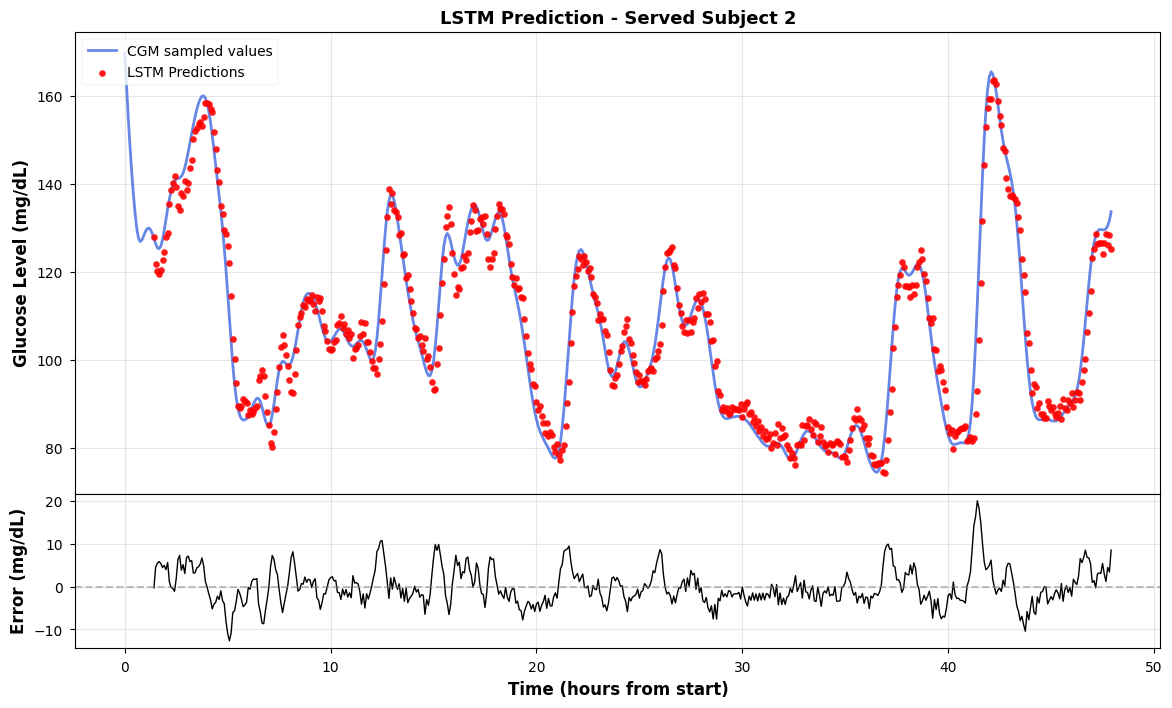

Served Subject 2: Visualization generated.


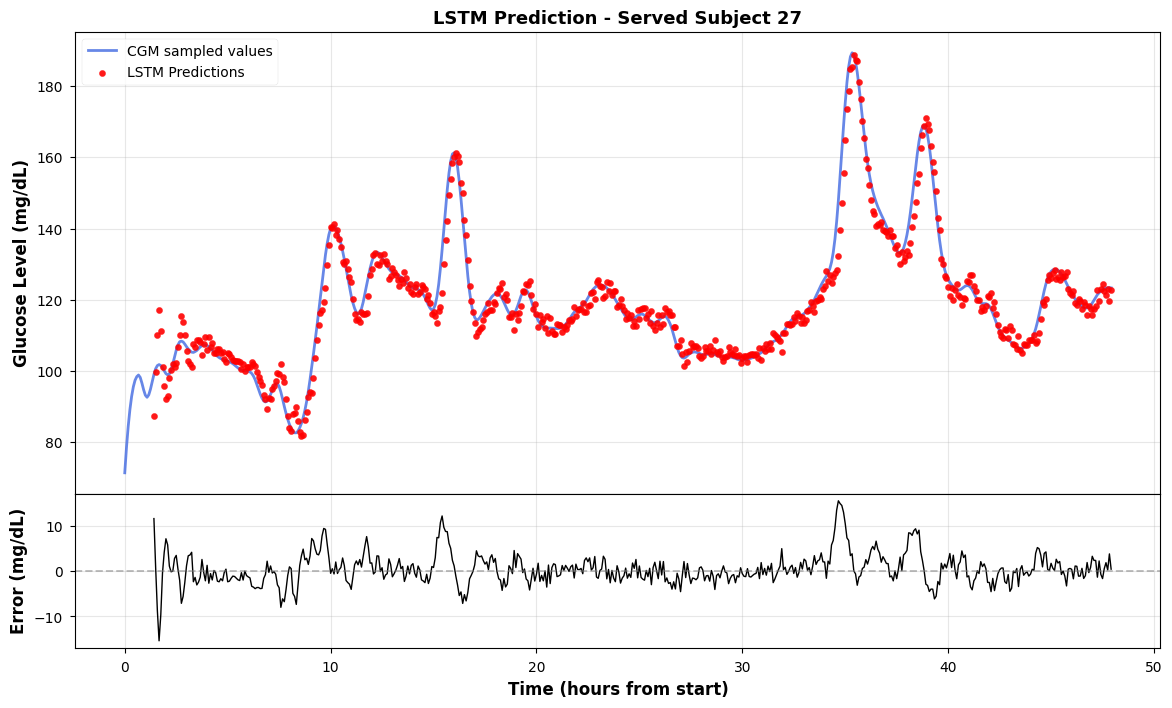

Served Subject 27: Visualization generated.


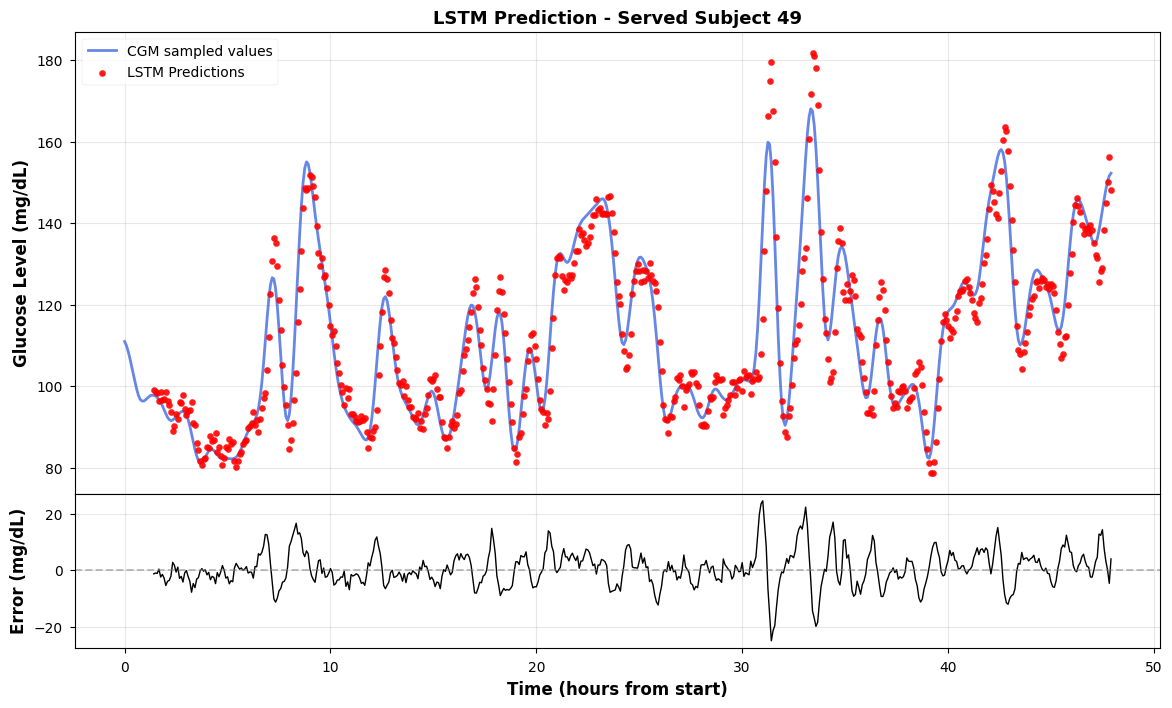

Served Subject 49: Visualization generated.


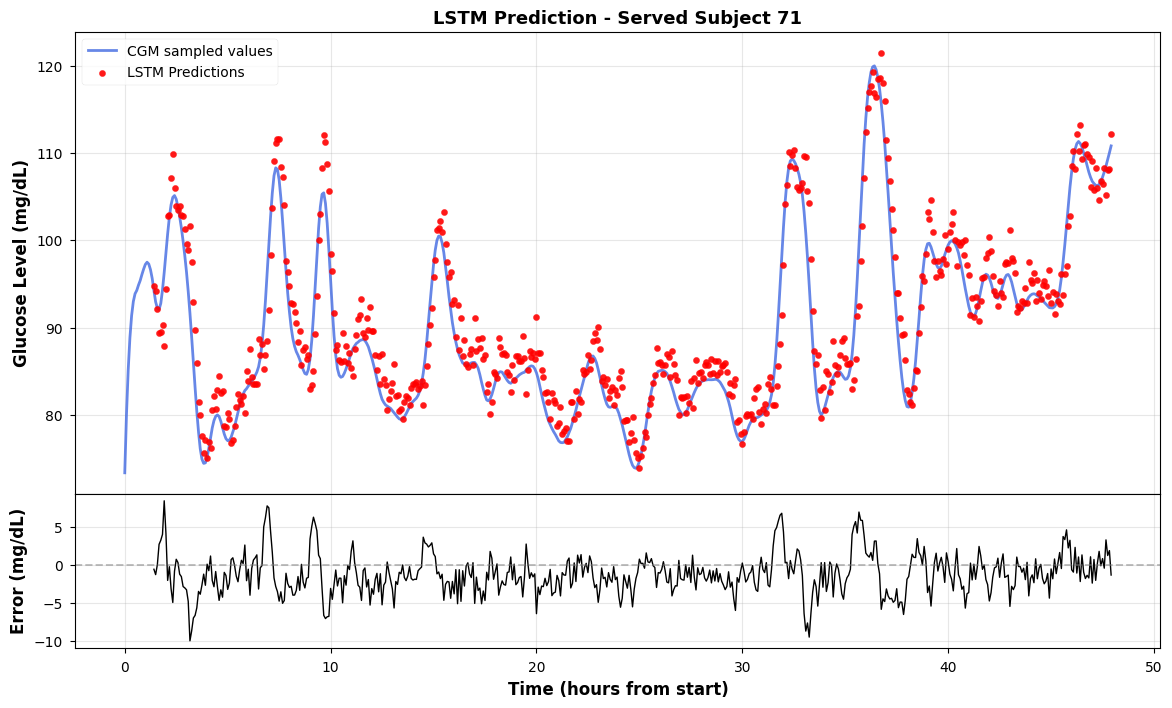

Served Subject 71: Visualization generated.


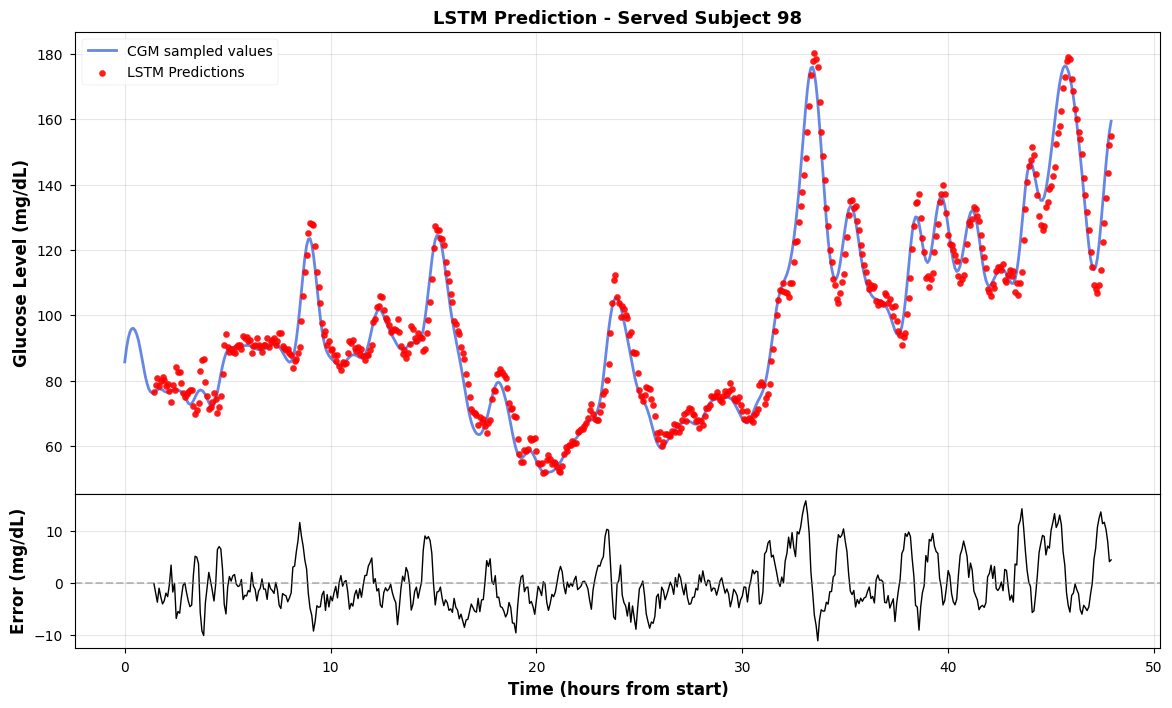

Served Subject 98: Visualization generated.


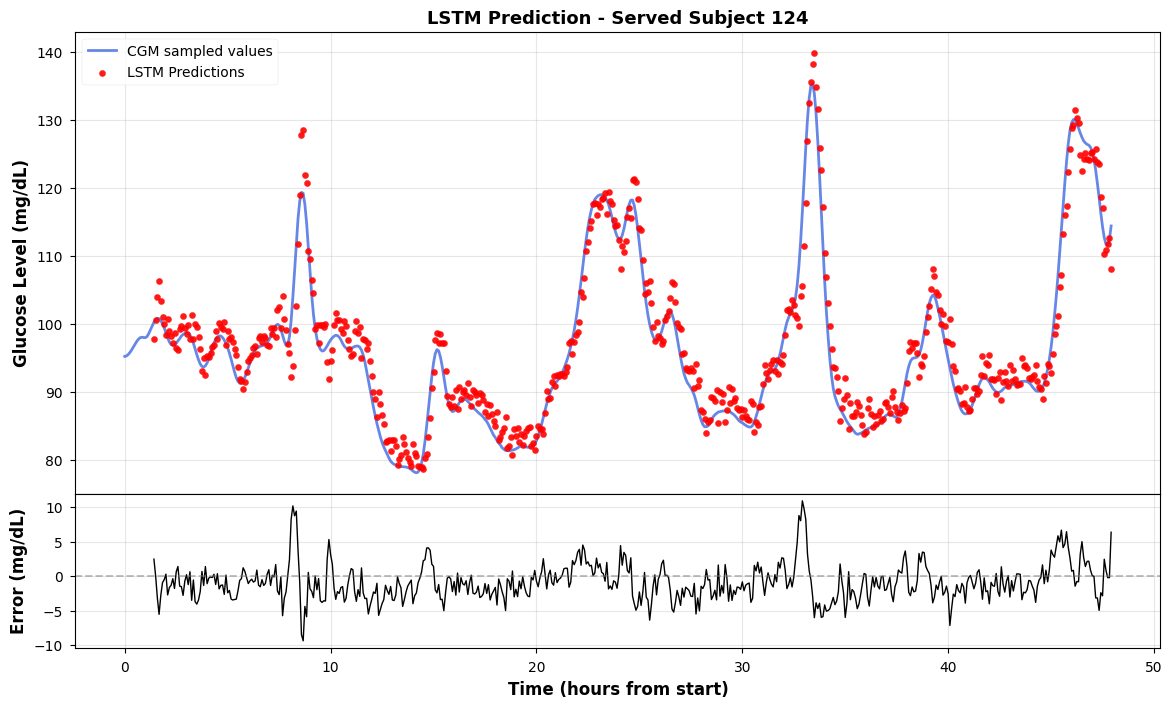

Served Subject 124: Visualization generated.


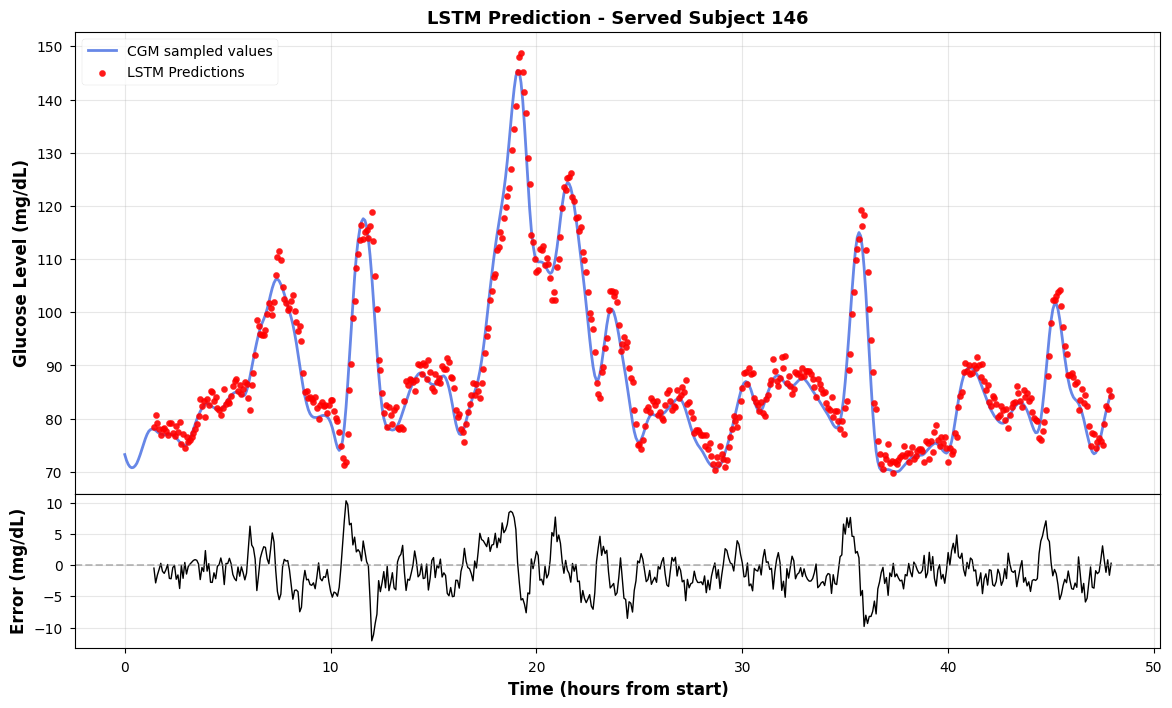

Served Subject 146: Visualization generated.


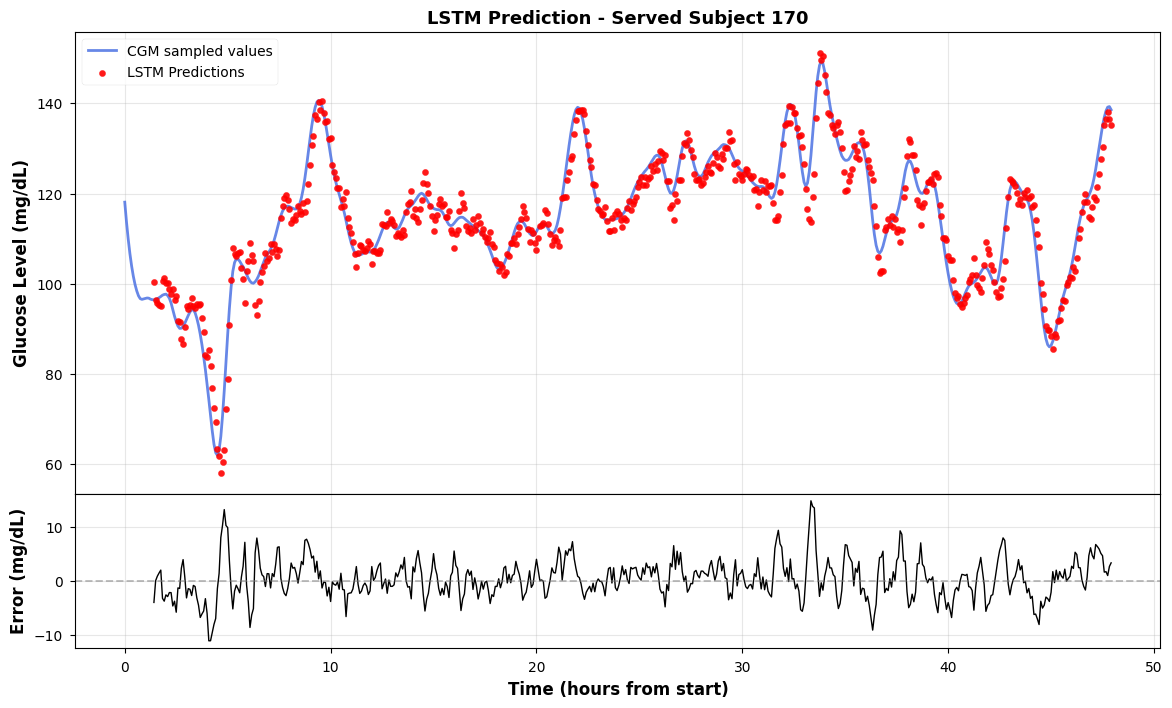

Served Subject 170: Visualization generated.


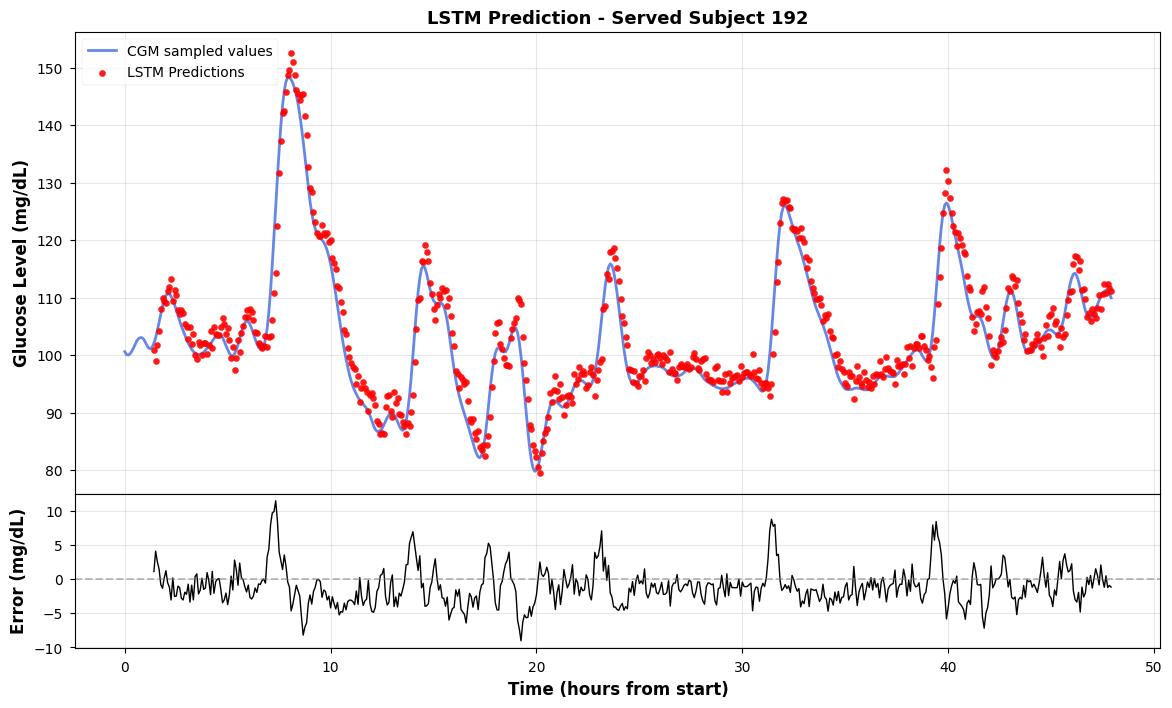

Served Subject 192: Visualization generated.


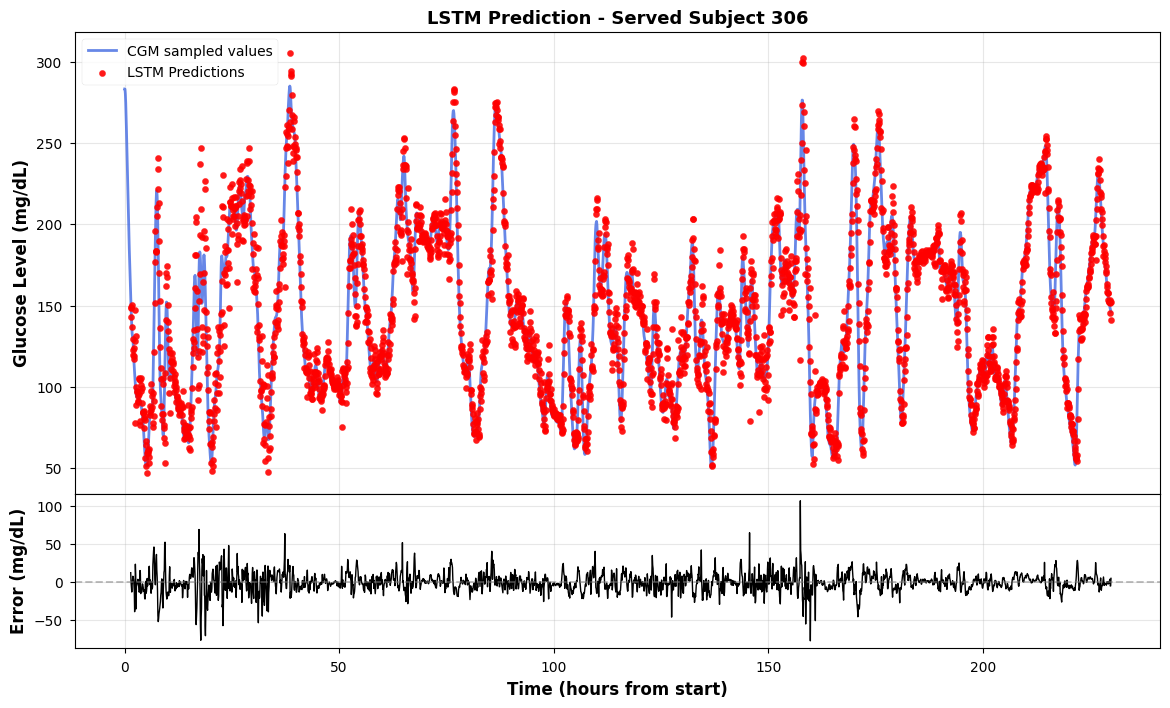

Served Subject 306: Visualization generated.


In [13]:
# --- 可视化 Served Set 预测结果 ---
subject_ids_served = sorted(df_served['id'].unique())
current_idx_s = 0

for subject_id in subject_ids_served:
    subject_data = df_served[df_served['id'] == subject_id].copy().sort_values('time')
    gl_values = subject_data['gl'].values
    
    n_valid = len(gl_values) - N_PAST - PREDICTION_HORIZON + 1
    if n_valid <= 0: continue
        
    y_pred_s = y_pred_served[current_idx_s : current_idx_s + n_valid]
    current_idx_s += n_valid
    
    full_hours = np.arange(len(subject_data)) * (5 / 60)
    pred_indices = np.arange(N_PAST + PREDICTION_HORIZON - 1, N_PAST + PREDICTION_HORIZON - 1 + n_valid)
    pred_hours = full_hours[pred_indices]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
    
    ax1.plot(full_hours, gl_values, label='CGM sampled values', color='royalblue', linewidth=2, alpha=0.8)
    ax1.scatter(pred_hours, y_pred_s, label=f'LSTM Predictions', color='red', s=20, alpha=0.9, zorder=5)
    ax1.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
    ax1.set_title(f'LSTM Prediction - Served Subject {subject_id}', fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    error_s = gl_values[pred_indices] - y_pred_s
    ax2.plot(pred_hours, error_s, label='Prediction Error', color='black', linewidth=1)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_ylabel('Error (mg/dL)', fontweight='bold')
    ax2.set_xlabel('Time (hours from start)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.show()
    print(f"Served Subject {subject_id}: Visualization generated.")

正在绘制标准 Clarke Error Grid...


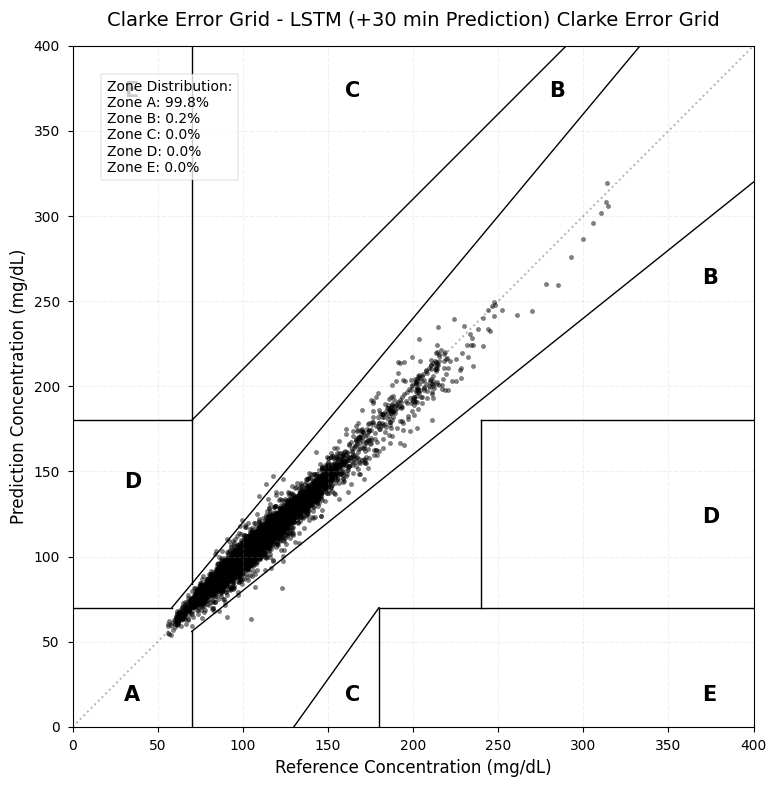


各区临床统计:
  Zone A: 99.82%
  Zone B: 0.18%
  Zone C: 0.00%
  Zone D: 0.00%
  Zone E: 0.00%
  A + B (临床安全): 100.00%


In [14]:
import sys
import os
import importlib

# 添加 utils 目录
utils_path = os.path.abspath('../../../utils')
if utils_path not in sys.path:
    sys.path.append(utils_path)

try:
    import ceg_utils
    importlib.reload(ceg_utils)
except ImportError:
    print(f"Error: Could not import ceg_utils from {utils_path}")

print("=" * 60)
print("正在绘制标准 Clarke Error Grid...")
print("=" * 60)

plt_obj, zones_pct_list = ceg_utils.clarke_error_grid(
    y_test_np, 
    y_pred, 
    title_string=f"Clarke Error Grid - LSTM (+{PREDICTION_HORIZON*5} min Prediction)"
)

plt_obj.show()

zones = ['A', 'B', 'C', 'D', 'E']
zones_pct = {z: p for z, p in zip(zones, zones_pct_list)}

print("\n各区临床统计:")
for zone in ['A', 'B', 'C', 'D', 'E']:
    print(f"  Zone {zone}: {zones_pct[zone]:.2f}%")
print(f"  A + B (临床安全): {zones_pct['A'] + zones_pct['B']:.2f}%")